# 📊 02. Análisis Exploratorio de Datos (EDA)

En esta notebook se realiza un análisis exploratorio del dataset con el objetivo de comprender la estructura de los datos, evaluar su calidad e identificar las variables más relevantes para los modelos predictivos.

---

## Contenido

1. 📁 Descripción del dataset
2. 🔍 Tipos de datos
3. 🧹 Calidad de los datos
   - Valores faltantes
   - Registros duplicados
4. 🎯 Análisis de la variable objetivo (`SalePrice`)
5. 📈 Análisis de variables numéricas
   - Distribuciones
   - Correlaciones
   - Redundancia
6. 🏷️ Análisis de variables categóricas
   - Relación con `SalePrice`
7. ✅ Selección preliminar de variables para el modelado

In [1]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sn
import plotly.express as px
from pathlib import Path
import seaborn as sns
print("librerias ok")

librerias ok


In [5]:
# Ruta del proyecto
ruta_proyecto = Path.cwd().parent
print(ruta_proyecto)
#Ruta donde se encuentra el dataset
ruta_raw = ruta_proyecto  /  "data" 

print(ruta_raw)

archivo = ruta_raw / "AmesHousing.csv"
df = pd.read_csv(archivo)

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML
d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\data


In [6]:
#Lo visualizamos
display(df.head())

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [7]:
#Eliminamos las dos columnas porque no van a hacer de interes
df = df.drop(columns = ["Order","PID"])
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [8]:
df.info()
#Este dataset tiene mas de 80 variables.

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   str    
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   str    
 5   Alley            198 non-null    str    
 6   Lot Shape        2930 non-null   str    
 7   Land Contour     2930 non-null   str    
 8   Utilities        2930 non-null   str    
 9   Lot Config       2930 non-null   str    
 10  Land Slope       2930 non-null   str    
 11  Neighborhood     2930 non-null   str    
 12  Condition 1      2930 non-null   str    
 13  Condition 2      2930 non-null   str    
 14  Bldg Type        2930 non-null   str    
 15  House Style      2930 non-null   str    
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond     2930 non

In [ ]:
#Cuantos valores faltantes hay y cuales son las columnas que afecta
datos_faltantes = (df.isna().sum().sort_values(ascending = False))
datos_faltantes = datos_faltantes[datos_faltantes > 0]
print(datos_faltantes)

#Igual hay que considerar que en algunos casos de ciertas columnas no significa falta de datos, sino de caracteristicas

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Yr Blt      159
Garage Qual        159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
BsmtFin Type 1      80
Bsmt Cond           80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 2         1
Garage Area          1
Total Bsmt SF        1
BsmtFin SF 1         1
Electrical           1
Bsmt Unf SF          1
Garage Cars          1
dtype: int64


In [9]:
# Hay datos duplicados?
df.duplicated().sum() 
#No, no hay datos duplicados

np.int64(0)

In [ ]:
# Tipos de datos
#Verificar que no haya números guardados como texto.
df.select_dtypes("object").columns

C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_14760\1014306322.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").columns


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')

In [10]:
# Esto sirve para saber cuáles conviene visualizar.
cat = df.select_dtypes(include="object")

cat.nunique().sort_values()

C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_15808\4040179679.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include="object")


Street             2
Alley              2
Central Air        2
Land Slope         3
Utilities          3
Garage Finish      3
Paved Drive        3
Land Contour       4
Exter Qual         4
Bsmt Exposure      4
Mas Vnr Type       4
Lot Shape          4
Fence              4
Pool QC            4
Bsmt Qual          5
Bsmt Cond          5
Electrical         5
Kitchen Qual       5
Garage Qual        5
Fireplace Qu       5
Exter Cond         5
Heating QC         5
Lot Config         5
Bldg Type          5
Misc Feature       5
Garage Cond        5
Heating            6
Foundation         6
BsmtFin Type 1     6
BsmtFin Type 2     6
Roof Style         6
Garage Type        6
Sale Condition     6
MS Zoning          7
House Style        8
Condition 2        8
Roof Matl          8
Functional         8
Condition 1        9
Sale Type         10
Exterior 1st      16
Exterior 2nd      17
Neighborhood      28
dtype: int64

Mediana 160000.0
Media 180796.06
SD 79886.69


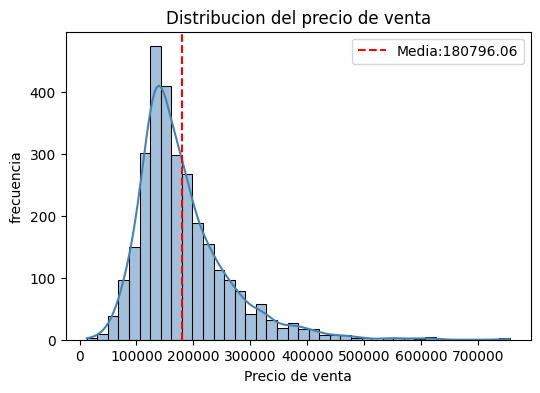

In [11]:
# Analizar la variable objetivo
df.columns
df['SalePrice'].describe()

#Metricas varias de la variable objetivo
print("Mediana", round(df['SalePrice'].median(),2))
print("Media",round(df['SalePrice'].mean(),2))
print("SD", round(df['SalePrice'].std(),2))

### Plot

plt.figure(figsize = (6, 4))
sns.histplot (data = df, x = 'SalePrice', bins = 40, kde = True, color = "steelblue")
plt.axvline (df['SalePrice'].mean(), color ="red", linestyle = "--", label = f"Media:{round(df['SalePrice'].mean(),2)}")
plt.title ("Distribucion del precio de venta")
plt.xlabel ("Precio de venta")
plt.ylabel ("frecuencia")
plt.legend()
plt.show()

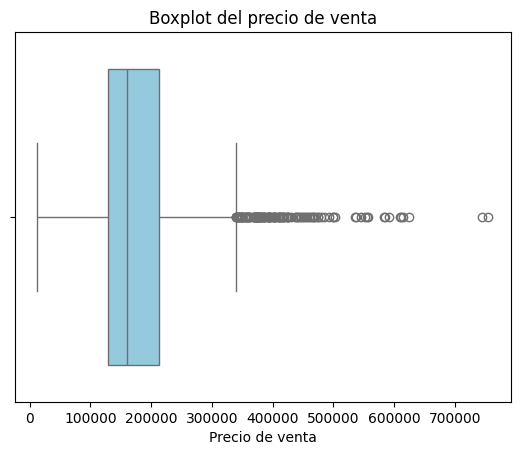

In [12]:
# Hacemos un boxplot
plt.Figure(figsize=(10,2))
sns.boxplot (x = df['SalePrice'], color ="skyblue")
plt.title ("Boxplot del precio de venta")
plt.xlabel ("Precio de venta")
plt.show()

#Vemos bastantes outliers, hay que ver que hacemos con estos datos?

Algunos comentarios:
- La media es bastante mayor que la mediana.
- Esto indica que la distribución probablemente esté sesgada hacia la derecha (asimetría positiva).
- Es decir, existen algunas viviendas muy costosas que elevan el promedio. 

In [13]:
# Separamos las variables numericas y de texto para un mejor analisis 
num_cols = df.select_dtypes(include = "number").columns
str_cols = df.select_dtypes (include = "object").columns

print(f"Cuales son las variables numericas {num_cols}")
print(f"Cuales son las variables de texto {str_cols}")

Cuales son las variables numericas Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'],
      dtype='str')
Cuales son las variables de texto Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exte

C:\Users\Josefina Urquiza\AppData\Local\Temp\ipykernel_15808\3712758275.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes (include = "object").columns


Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0.706780
Overall Qual       0

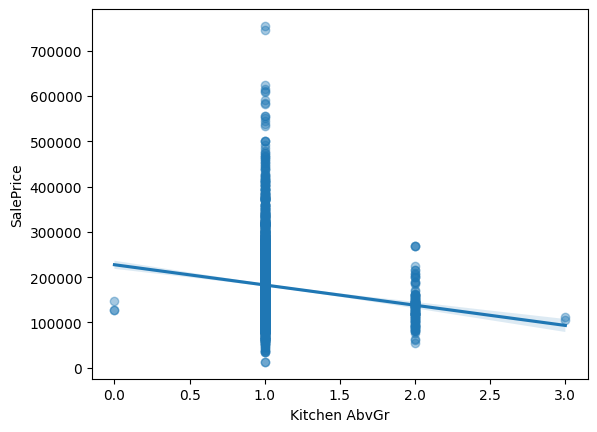

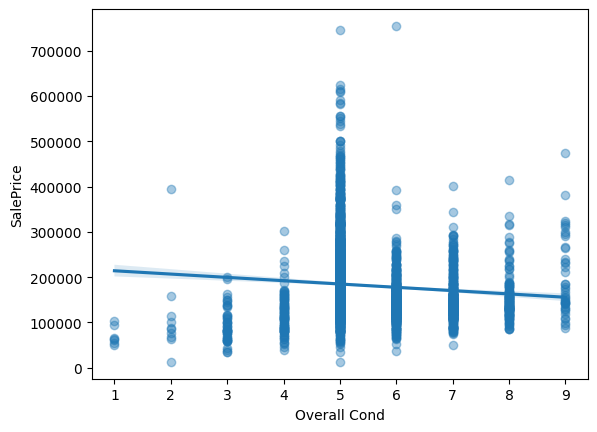

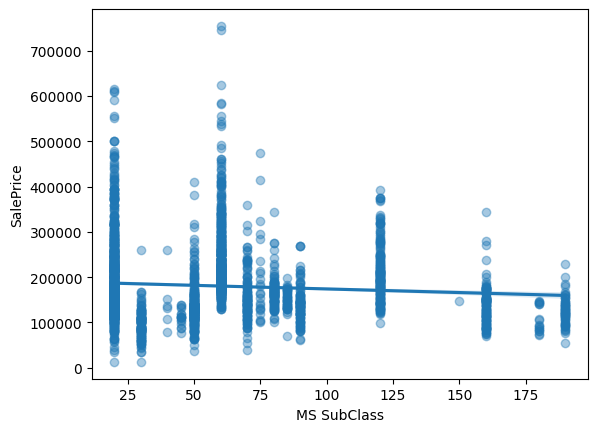

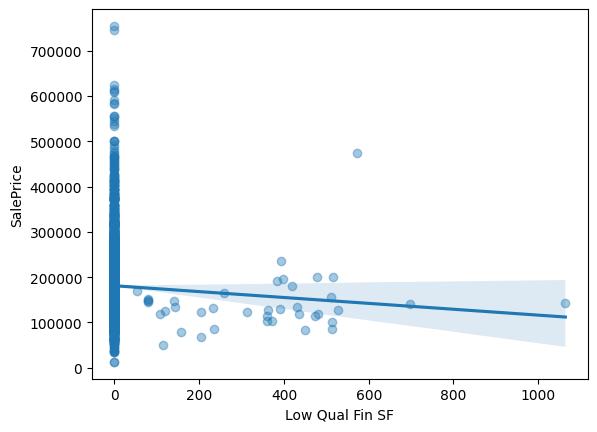

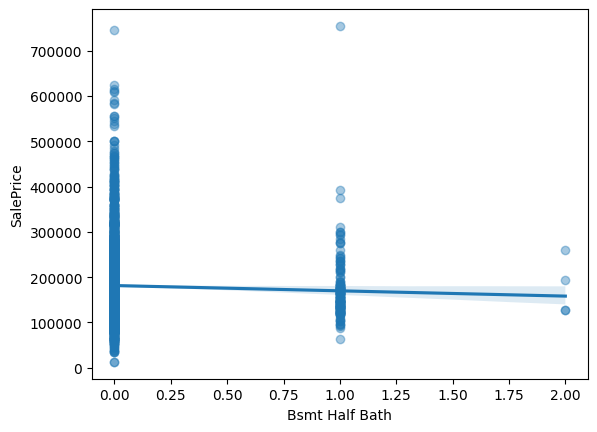

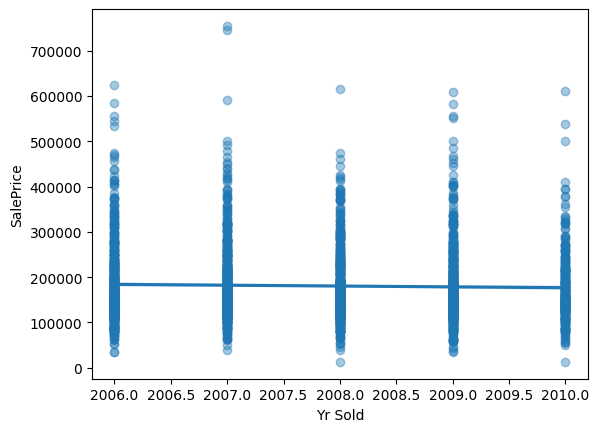

In [14]:
#Buscar que variables estan mas relacionadas con la variable objetivo a traves de una correlacion
corr = (df[num_cols].corr(numeric_only = True)['SalePrice'].sort_values (ascending = True))

print(corr)
# Se muestran las mas importantes
corr.head(10)

# Hacemos un plot para entenderlo mejor
variables = corr.index[1:7]
for var in variables:
    sns.regplot (data = df, x = var, y = "SalePrice", scatter_kws = {"alpha":0.4})
    plt.show()

In [ ]:
# Analizar las variables categóricas 
cat_info = pd.DataFrame({ "Categorias": df[str_cols].nunique()}).sort_values("Categorias")

cat_info
# Esto muestra cuantas categorias hay por cada columna

,Categorias
Street,2
Alley,2
Central Air,2
Land Slope,3
Utilities,3
Garage Finish,3
Paved Drive,3
Land Contour,4
Exter Qual,4
Bsmt Exposure,4


Las variables categóricas presentan una cardinalidad muy variada. Mientras que algunas poseen únicamente dos categorías (por ejemplo, Street, Alley y Central Air), otras contienen un número considerablemente mayor, como Neighborhood (28 categorías), Exterior 2nd (17 categorías) y Exterior 1st (16 categorías). Esta diferencia será relevante al momento de visualizar los datos y durante el preprocesamiento para los modelos de aprendizaje automático.

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0

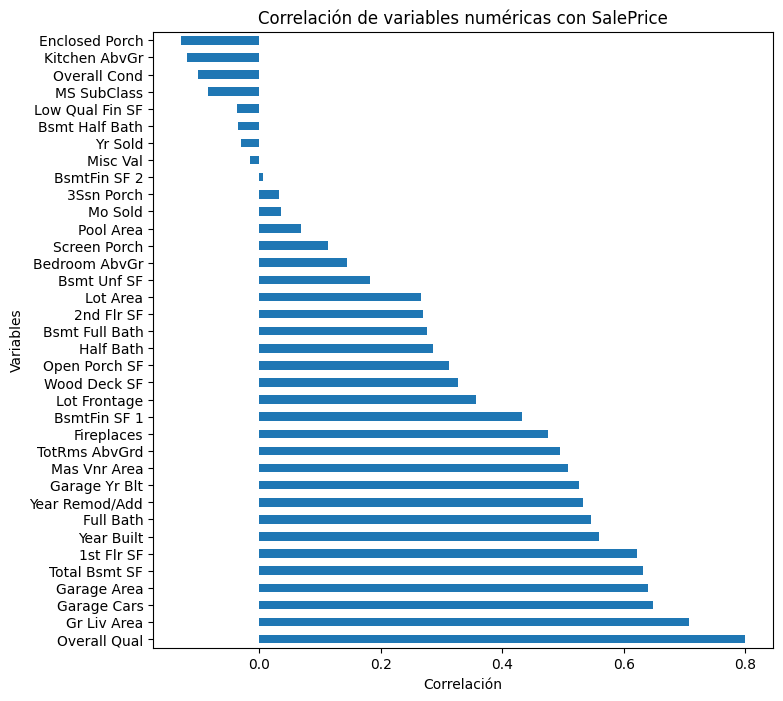

In [ ]:
# Intentamos hacer un filtro de las variables en relacion con la variable objetivo

correlacion = (df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False))
print(correlacion)

#Plot
plt.figure(figsize=(8,8))

correlacion.drop("SalePrice").plot(kind="barh")

plt.title("Correlación de variables numéricas con SalePrice")
plt.xlabel("Correlación")
plt.ylabel("Variables")

plt.show()

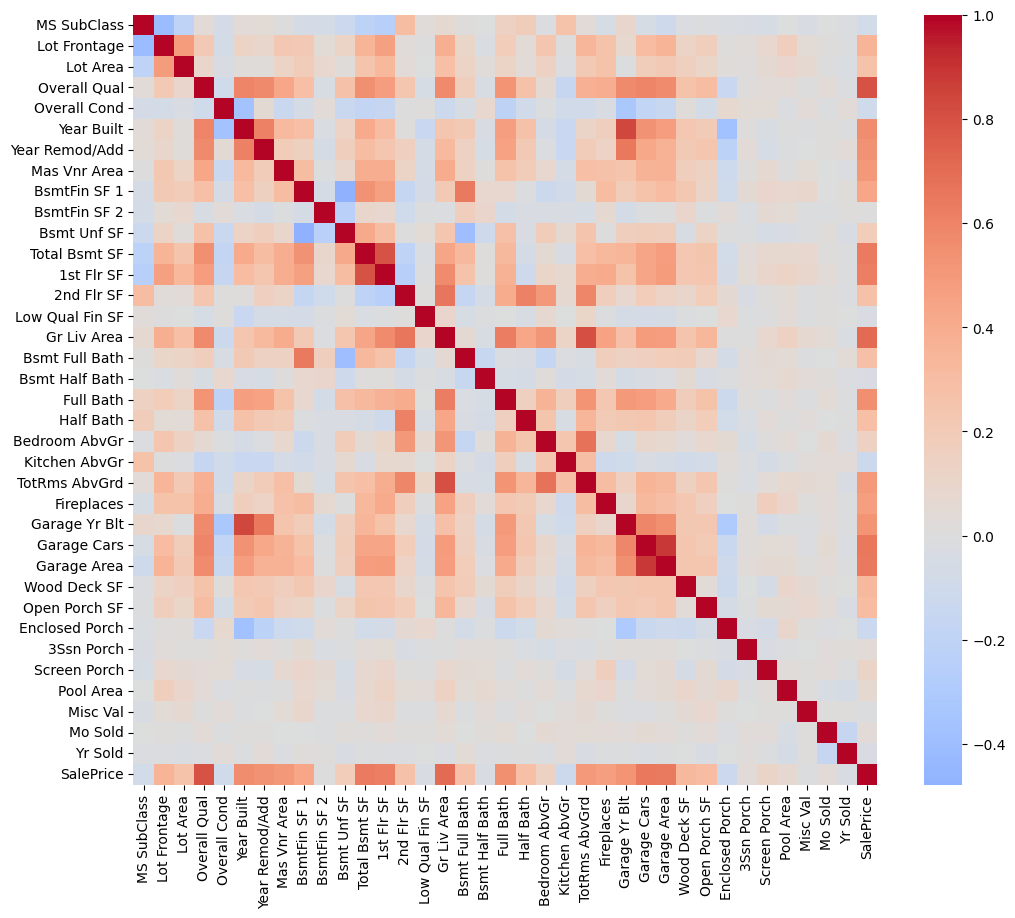

In [ ]:
#Matriz de correlacion entre todas las variables para evitar que se duplique la informacion

plt.figure(figsize=(12,10))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.show()

Garage Cars    Garage Area      0.889676
Garage Area    Garage Cars      0.889676
Year Built     Garage Yr Blt    0.834849
Garage Yr Blt  Year Built       0.834849
Gr Liv Area    TotRms AbvGrd    0.807772
TotRms AbvGrd  Gr Liv Area      0.807772
1st Flr SF     Total Bsmt SF    0.800720
Total Bsmt SF  1st Flr SF       0.800720
dtype: float64


Text(0.5, 0, 'Correlacion')

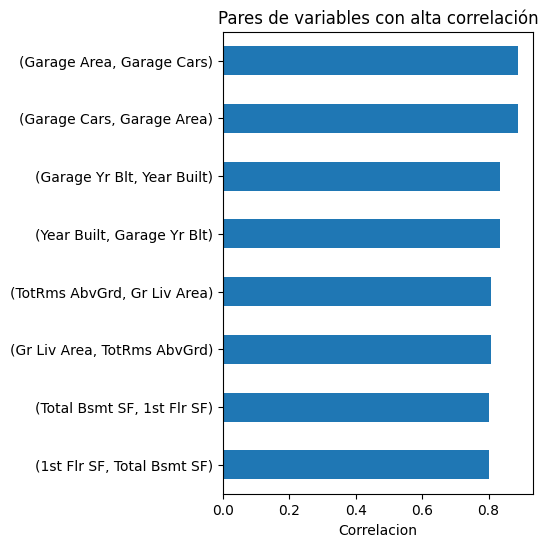

In [ ]:
#Cuales son los pares con alta correlacion entre si
corr = df.corr(numeric_only=True)

# pares con alta correlación (ej > 0.8)
high_corr = (
    corr.where((abs(corr) > 0.8) & (abs(corr) != 1) & (abs(corr) != "NaN"))
         .stack()
         .dropna()
         .sort_values(ascending=False)
)
print(high_corr)


# Plot con esa info
high_corr.sort_values().plot(kind = "barh", figsize = (4,6))
plt.title ("Pares de variables con alta correlación")
plt.xlabel ("Correlacion")

Se identificaron variables altamente correlacionadas entre sí, lo que sugiere redundancia de información:
 - 4 pares con alta correlación (> 0.8).
 - Garage Cars ↔ Garage Area (0.89), miden cantidad de autos y tamaño del garage, son variables redundantes. Se elige Garage Area para continuar con el analisis.
 - Year Built ↔ Garage Yr Blt (0.83),  mide por un lado Casas nuevas → garages nuevos que en resumen estan relacionadas con la antigüedad de la propiedad. Nos quedamos con Year Built.
 - Gr Liv Area ↔ TotRms AbvGrd (0.81), tamaño vs cantidad de habitaciones, hay una fuerte redundancia pero se selecciona Gr Liv Area para continuar con el analisis.
 - 1st Flr SF ↔ Total Bsmt SF (0.80), tamaño planta baja vs sótano, se podria decir que estan relacionados estructuralmente. Se selecciona 1st Flr SF para continuar


#### Variables categoricas como las tratamos?
Hay algunas que se pueden tratar como:
1. Binarias (2 categorías): Central Air; Street
2. Ordinales (tienen orden): Kitchen Qual; Exter Qual; Bsmt Qual
3. Nominales (sin orden): Neighborhood; House Style; Foundation con One-Hot Encoding

Sale Condition
AdjLand    110000.0
Abnorml    129450.0
Family     144400.0
Alloca     149617.0
Normal     159000.0
Partial    250000.0
Name: SalePrice, dtype: float64
Valores unicos de Sale Condition: 6


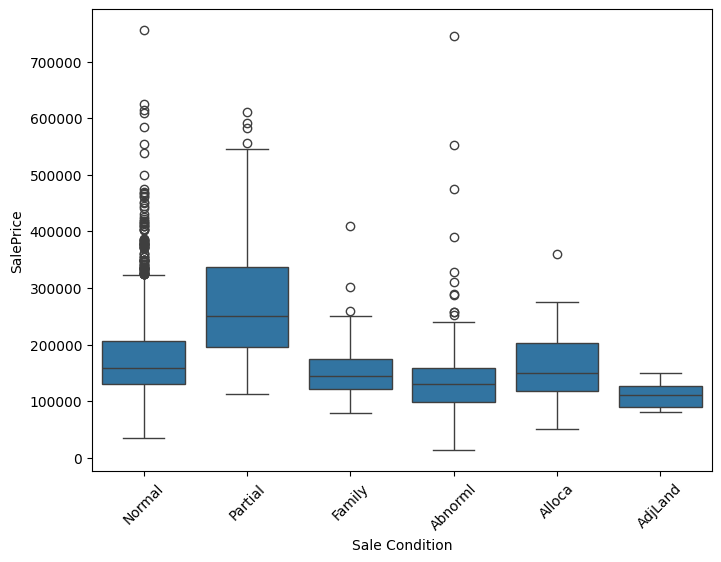

In [ ]:
# Empezamos a analizar algunas de esas variables categoricas
# por ejemplo Neighborhood

cat_vars = ["Neighborhood", "Kitchen Qual", "Exter Qual", 
            "Bsmt Qual", "Garage Finish", "House Style", 
            "Foundation", "Sale Condition"]


variable = "Sale Condition"
print(df.groupby(variable)["SalePrice"].median().sort_values())

valores_unicos = df[variable].nunique()
print(f"Valores unicos de {variable}: {valores_unicos}")


#Plot
plt.figure (figsize = (8,6))
sns.boxplot (df, x=variable, y ="SalePrice")
plt.xticks (rotation = 45)
plt.show()

# En este caso esto muestra si esta variable: se separa por precios; tiene poder predictivo o si aporta información real. 
# Mientras que el boxplot permite  ver la dispersion, los outliers y la diferencias entre barrios

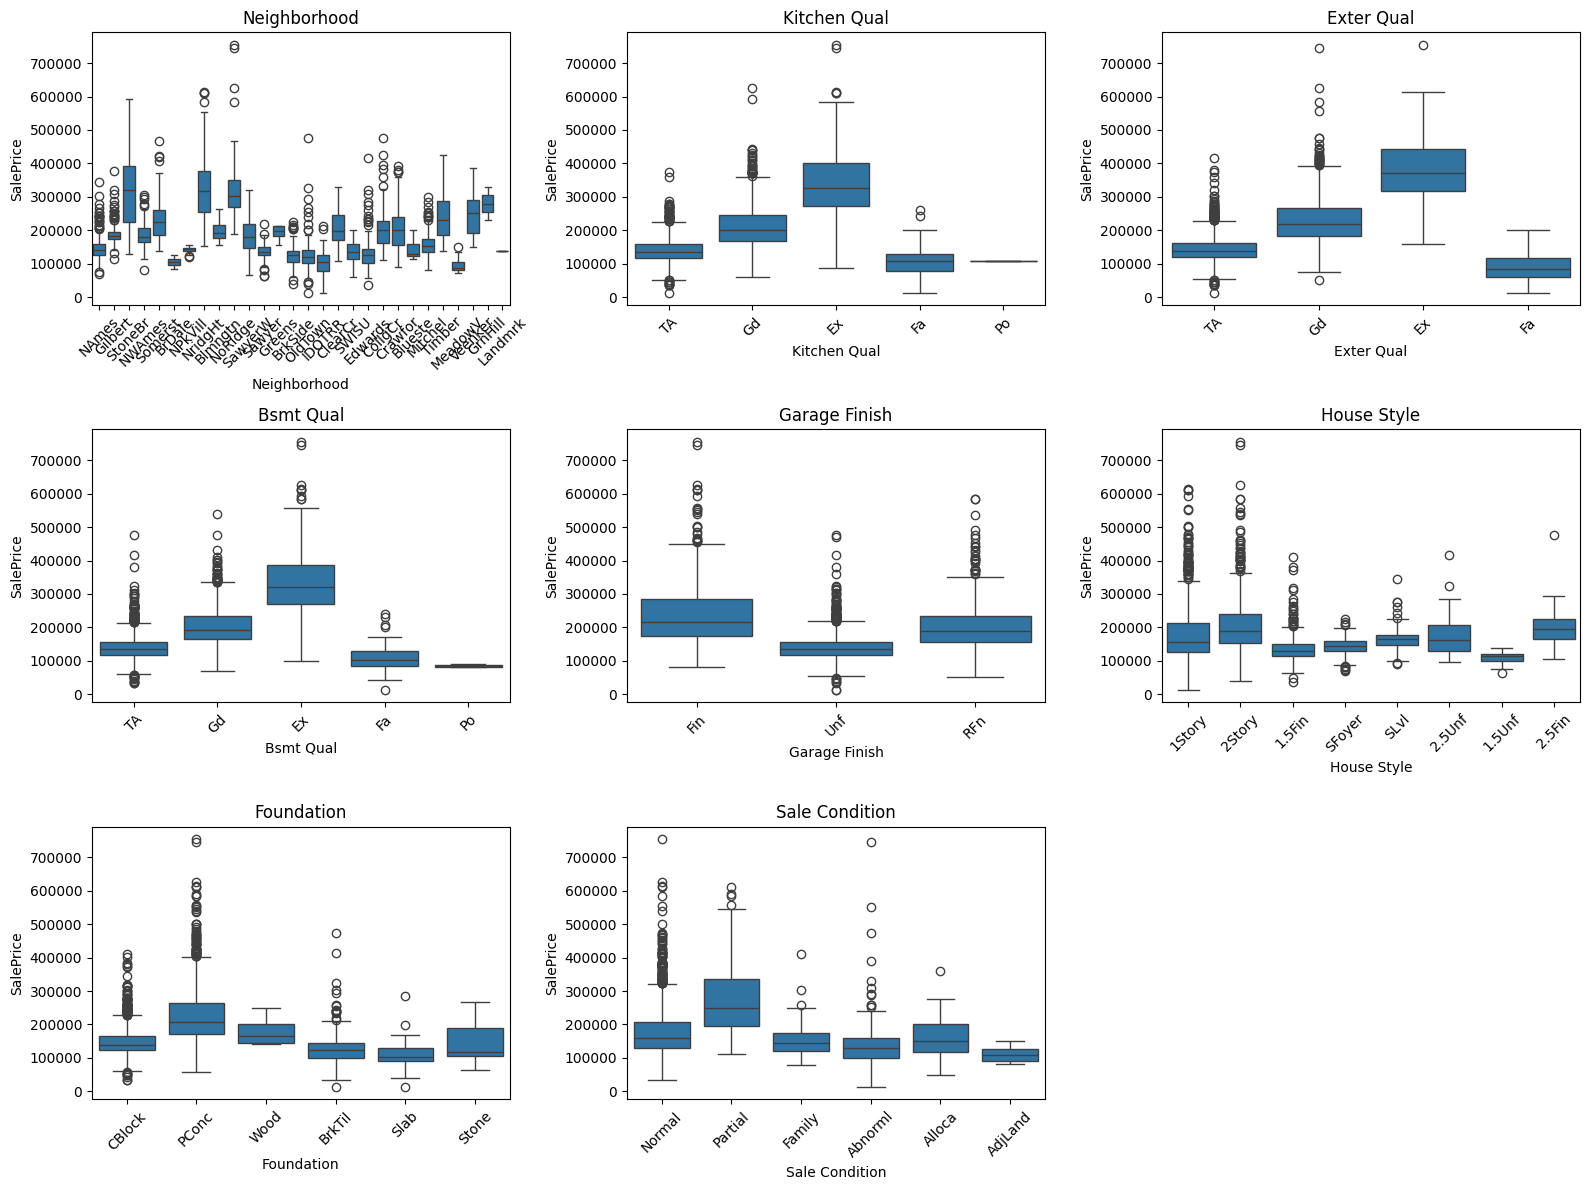

In [ ]:
# Se puede hacer de una forma mas eficiente con todas las variables
#Prueba
cat_vars = ["Neighborhood", "Kitchen Qual", "Exter Qual", 
            "Bsmt Qual", "Garage Finish", "House Style", 
            "Foundation", "Sale Condition"]

plt.figure(figsize = (16,12))

for i, var in enumerate(cat_vars):
    plt.subplot(3, 3, i+1)
    
    sns.boxplot(data=df, x=var, y="SalePrice")
    plt.xticks(rotation = 45)
    plt.title(var)

plt.tight_layout()
plt.show()



##### *Explicación por variables:*
- *Kitchen Qual*: muestra una relación monótona y muy fuerte, que dice que a peor calidad → menor precio y viceversa
- *Exter Qual*: idem anterior muestra la calidad percibida de la vivienda, peor calidad exterior → casas baratas, mejor calidad exterior → casas caras. Por ejemplo resume las caracteristicas de los materiales, mantenimiento, construcción, estética entre otras.
- *Bsmt Qual*: idem anteriores: peor sótano → casas más baratas; mejor sótano → casas más caras.
- *Garage Finish*: diferencia con las anteriores hay un patrón general positivo, donde peor acabado → menor precio; mejor acabado → mayor precio. Pero ojo no perfectamente ordinal en “intensidad”. Podemos decir que es importante pero menos fuerte que las anteriores. Particularmente creo que no lo agregaria porque no hay tanta variabilidad como las anteriores.
- *House Style* hay relación con el precio pero no es perfectamente ordinal, porque no sigue una escala de “mejor → peor” sino que mezcla tipos de construcción, no calidad. Hay mucho solapamiento entre categorías.
- *Foundation*: empieza a mezclar estructura + calidad implícita, hay relación con el precio pero el patrón NO es perfectamente “ordinal natural”
- *Sale Condition*: la mayoría de categorías tienen impacto limitado. Me parece una variable entre débil a media como predictor estructural porque depende del tipo de venta, no de la casa en si y ademas porque puede introducir ruido si no se controla. no se tiene cuenta.


Con estos plots la idea es ver en que variables hay una separacion calra de precios.

**Variables muy fuertes:**
- Neighborhood
- Kitchen Qual
- Exter Qual
- Bsmt Qual

**Veriables importantes pero no críticas**
- Garage Finish
- Foundation

**Variables débiles**
- House Style
- Sale Condition

In [ ]:
pd.crosstab(df["Kitchen Qual"], df["Exter Qual"])

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape)-1)))

Exter Qual
Kitchen Qual


In [ ]:
# Variables finalmente selccionadas para el modelo

variables_modelo = [

    # Variable objetivo
    "SalePrice",
    # Variables numéricas
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "Mas Vnr Area",
    "Fireplaces",
    "Lot Area",
    "Lot Frontage",
    "Wood Deck SF",
    "Open Porch SF",
    # Variables categóricas
    "Neighborhood",
    "Kitchen Qual",
    "Exter Qual",
    "Bsmt Qual",
    "Garage Finish",
    "Foundation",
    "House Style",
    "Sale Condition"
]

# Crear un nuevo DataFrame únicamente con las variables seleccionadas
df_model = df[variables_modelo].copy()

print(df_model.shape)
df_model.head()

(2930, 22)


,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,Fireplaces,...,Wood Deck SF,Open Porch SF,Neighborhood,Kitchen Qual,Exter Qual,Bsmt Qual,Garage Finish,Foundation,House Style,Sale Condition
0,215000,6,1656,1080.0,528.0,1960,1960,1,112.0,2,...,210,62,NAmes,TA,TA,TA,Fin,CBlock,1Story,Normal
1,105000,5,896,882.0,730.0,1961,1961,1,0.0,0,...,140,0,NAmes,TA,TA,TA,Unf,CBlock,1Story,Normal
2,172000,6,1329,1329.0,312.0,1958,1958,1,108.0,0,...,393,36,NAmes,Gd,TA,TA,Unf,CBlock,1Story,Normal
3,244000,7,2110,2110.0,522.0,1968,1968,2,0.0,2,...,0,0,NAmes,Ex,Gd,TA,Fin,CBlock,1Story,Normal
4,189900,5,1629,928.0,482.0,1997,1998,2,0.0,1,...,212,34,Gilbert,TA,TA,Gd,Fin,PConc,2Story,Normal


In [ ]:
print("Cantidad de variables:", len(df_model.columns))
print(df_model.columns.tolist())

Cantidad de variables: 22
['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF', 'Garage Area', 'Year Built', 'Year Remod/Add', 'Full Bath', 'Mas Vnr Area', 'Fireplaces', 'Lot Area', 'Lot Frontage', 'Wood Deck SF', 'Open Porch SF', 'Neighborhood', 'Kitchen Qual', 'Exter Qual', 'Bsmt Qual', 'Garage Finish', 'Foundation', 'House Style', 'Sale Condition']


In [ ]:
#Guardamos dataset para despues usarlo directamente
df_model.to_csv("./data/AmesHousing_modificado.csv")